In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set global graph style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# --- 1. TREES (100) ---
trees = [
    {'name':'Date Palm', 'region':'Saudi/India', 'temp_min':25,'temp_max':50,'humidity_min':10,'humidity_max':40,'ph_min':7.0,'ph_max':8.5,'soil_moisture_min':10,'soil_moisture_max':30,'light_min':85,'light_max':100,'rain_min':0,'rain_max':150,'grow_days':1095,'water_need':'Low','priority':10},
    {'name':'Olive', 'region':'Saudi/India', 'temp_min':10,'temp_max':40,'humidity_min':25,'humidity_max':60,'ph_min':5.5,'ph_max':8.5,'soil_moisture_min':20,'soil_moisture_max':45,'light_min':80,'light_max':100,'rain_min':250,'rain_max':700,'grow_days':1460,'water_need':'Low','priority':10},
    {'name':'Pomegranate', 'region':'Saudi/India', 'temp_min':18,'temp_max':38,'humidity_min':20,'humidity_max':50,'ph_min':5.5,'ph_max':7.2,'soil_moisture_min':20,'soil_moisture_max':45,'light_min':75,'light_max':100,'rain_min':200,'rain_max':700,'grow_days':730,'water_need':'Low','priority':10},
    {'name':'Fig', 'region':'Saudi/India', 'temp_min':15,'temp_max':38,'humidity_min':20,'humidity_max':55,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':20,'soil_moisture_max':45,'light_min':75,'light_max':100,'rain_min':300,'rain_max':800,'grow_days':730,'water_need':'Low','priority':9},
    {'name':'Moringa', 'region':'Saudi/India', 'temp_min':20,'temp_max':42,'humidity_min':20,'humidity_max':65,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':15,'soil_moisture_max':45,'light_min':75,'light_max':100,'rain_min':250,'rain_max':1500,'grow_days':180,'water_need':'Low','priority':10},
    {'name':'Acacia', 'region':'Saudi', 'temp_min':20,'temp_max':48,'humidity_min':5,'humidity_max':35,'ph_min':6.0,'ph_max':8.5,'soil_moisture_min':5,'soil_moisture_max':25,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':730,'water_need':'Low','priority':9},
    {'name':'Sidr (Lote Tree)', 'region':'Saudi', 'temp_min':20,'temp_max':45,'humidity_min':10,'humidity_max':40,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':10,'soil_moisture_max':30,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':1095,'water_need':'Low','priority':9},
    {'name':'Tamarind', 'region':'Saudi/India', 'temp_min':20,'temp_max':40,'humidity_min':30,'humidity_max':70,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':75,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':1825,'water_need':'Low','priority':8},
    {'name':'Ghaf Tree', 'region':'Saudi', 'temp_min':22,'temp_max':50,'humidity_min':5,'humidity_max':30,'ph_min':7.0,'ph_max':9.0,'soil_moisture_min':5,'soil_moisture_max':20,'light_min':85,'light_max':100,'rain_min':50,'rain_max':300,'grow_days':730,'water_need':'Low','priority':9},
    {'name':'Neem', 'region':'Saudi/India', 'temp_min':20,'temp_max':45,'humidity_min':20,'humidity_max':60,'ph_min':6.2,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':40,'light_min':75,'light_max':100,'rain_min':400,'rain_max':1200,'grow_days':730,'water_need':'Low','priority':8},
    {'name':'Mango', 'region':'India', 'temp_min':24,'temp_max':30,'humidity_min':50,'humidity_max':80,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':40,'soil_moisture_max':70,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1000,'grow_days':1825,'water_need':'Medium','priority':10},
    {'name':'Lemon', 'region':'Saudi/India', 'temp_min':23,'temp_max':30,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':730,'water_need':'Medium','priority':9},
    {'name':'Orange', 'region':'Saudi/India', 'temp_min':23,'temp_max':30,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':9},
    {'name':'Banana', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':75,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':65,'soil_moisture_max':85,'light_min':65,'light_max':100,'rain_min':1200,'rain_max':2500,'grow_days':300,'water_need':'High','priority':9},
    {'name':'Coconut', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':70,'light_max':100,'rain_min':1500,'rain_max':3000,'grow_days':2190,'water_need':'High','priority':8},
    {'name':'Papaya', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':55,'humidity_max':80,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':50,'soil_moisture_max':75,'light_min':70,'light_max':100,'rain_min':1000,'rain_max':1500,'grow_days':270,'water_need':'Medium','priority':9},
    {'name':'Guava', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':40,'humidity_max':75,'ph_min':5.0,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':700,'rain_max':1000,'grow_days':365,'water_need':'Low','priority':9},
    {'name':'Jackfruit', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':60,'humidity_max':85,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':50,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1500,'rain_max':2500,'grow_days':1095,'water_need':'High','priority':8},
    {'name':'Jamun (Java Plum)', 'region':'India', 'temp_min':18,'temp_max':38,'humidity_min':40,'humidity_max':75,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':800,'rain_max':1800,'grow_days':1095,'water_need':'Low','priority':8},
    {'name':'Amla (Indian Gooseberry)', 'region':'India', 'temp_min':18,'temp_max':38,'humidity_min':40,'humidity_max':75,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':30,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':600,'rain_max':1500,'grow_days':1095,'water_need':'Low','priority':9},
    {'name':'Mulberry', 'region':'India', 'temp_min':15,'temp_max':38,'humidity_min':40,'humidity_max':75,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':600,'rain_max':1500,'grow_days':365,'water_need':'Medium','priority':7},
    {'name':'Sapodilla (Chiku)', 'region':'India', 'temp_min':20,'temp_max':38,'humidity_min':50,'humidity_max':80,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':45,'soil_moisture_max':70,'light_min':70,'light_max':100,'rain_min':1250,'rain_max':2500,'grow_days':1460,'water_need':'Medium','priority':8},
    {'name':'Custard Apple', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':45,'humidity_max':75,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':40,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':700,'rain_max':1500,'grow_days':730,'water_need':'Low','priority':8},
    {'name':'Kokum', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':65,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':60,'light_max':90,'rain_min':2000,'rain_max':4000,'grow_days':1825,'water_need':'High','priority':7},
    {'name':'Apple', 'region':'World', 'temp_min':5,'temp_max':25,'humidity_min':45,'humidity_max':75,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':40,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':600,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':7},
    {'name':'Pear', 'region':'World', 'temp_min':5,'temp_max':25,'humidity_min':45,'humidity_max':70,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':40,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':600,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Cherry', 'region':'World', 'temp_min':5,'temp_max':22,'humidity_min':45,'humidity_max':70,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':65,'light_max':100,'rain_min':600,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Peach', 'region':'World', 'temp_min':5,'temp_max':28,'humidity_min':40,'humidity_max':70,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':65,'light_max':100,'rain_min':500,'rain_max':1000,'grow_days':730,'water_need':'Medium','priority':6},
    {'name':'Plum', 'region':'World', 'temp_min':5,'temp_max':28,'humidity_min':45,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':65,'light_max':100,'rain_min':500,'rain_max':1000,'grow_days':730,'water_need':'Medium','priority':6},
    {'name':'Apricot', 'region':'World', 'temp_min':5,'temp_max':30,'humidity_min':30,'humidity_max':60,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':300,'rain_max':700,'grow_days':730,'water_need':'Low','priority':7},
    {'name':'Avocado', 'region':'World', 'temp_min':15,'temp_max':30,'humidity_min':55,'humidity_max':80,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':45,'soil_moisture_max':70,'light_min':65,'light_max':100,'rain_min':1000,'rain_max':1800,'grow_days':1825,'water_need':'Medium','priority':7},
    {'name':'Grape (Vine)', 'region':'Saudi/India', 'temp_min':15,'temp_max':35,'humidity_min':25,'humidity_max':60,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':25,'soil_moisture_max':50,'light_min':75,'light_max':100,'rain_min':300,'rain_max':700,'grow_days':730,'water_need':'Low','priority':8},
    {'name':'Persimmon', 'region':'World', 'temp_min':10,'temp_max':30,'humidity_min':40,'humidity_max':70,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':500,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Lychee', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':65,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1200,'rain_max':2000,'grow_days':1095,'water_need':'High','priority':8},
    {'name':'Starfruit (Carambola)', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':60,'humidity_max':85,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':50,'soil_moisture_max':75,'light_min':65,'light_max':100,'rain_min':1500,'rain_max':2500,'grow_days':365,'water_need':'Medium','priority':7},
    {'name':'Longan', 'region':'World', 'temp_min':20,'temp_max':33,'humidity_min':65,'humidity_max':85,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':50,'soil_moisture_max':75,'light_min':65,'light_max':100,'rain_min':1200,'rain_max':2000,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Rambutan', 'region':'World', 'temp_min':22,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':65,'light_max':100,'rain_min':2000,'rain_max':3500,'grow_days':1095,'water_need':'High','priority':5},
    {'name':'Dragon Fruit', 'region':'World', 'temp_min':20,'temp_max':38,'humidity_min':40,'humidity_max':70,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':30,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':400,'rain_max':1000,'grow_days':365,'water_need':'Low','priority':7},
    {'name':'Passion Fruit', 'region':'World', 'temp_min':18,'temp_max':32,'humidity_min':55,'humidity_max':80,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':45,'soil_moisture_max':70,'light_min':65,'light_max':100,'rain_min':900,'rain_max':1800,'grow_days':365,'water_need':'Medium','priority':6},
    {'name':'Kiwi', 'region':'World', 'temp_min':10,'temp_max':28,'humidity_min':50,'humidity_max':80,'ph_min':6.0,'ph_max':6.5,'soil_moisture_min':50,'soil_moisture_max':70,'light_min':60,'light_max':100,'rain_min':800,'rain_max':1500,'grow_days':1095,'water_need':'Medium','priority':6},{'name':'White Mulberry', 'region':'India', 'temp_min':12,'temp_max':38,'humidity_min':40,'humidity_max':75,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':60,'light_max':100,'rain_min':600,'rain_max':1500,'grow_days':365,'water_need':'Medium','priority':7},
    {'name':'Pineapple', 'region':'India', 'temp_min':20,'temp_max':35,'humidity_min':60,'humidity_max':85,'ph_min':4.5,'ph_max':6.5,'soil_moisture_min':50,'soil_moisture_max':75,'light_min':65,'light_max':100,'rain_min':1000,'rain_max':2000,'grow_days':540,'water_need':'Medium','priority':8},
    {'name':'Breadfruit', 'region':'World', 'temp_min':22,'temp_max':35,'humidity_min':65,'humidity_max':90,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1500,'rain_max':3000,'grow_days':1095,'water_need':'High','priority':5},
    {'name':'Durian', 'region':'World', 'temp_min':24,'temp_max':35,'humidity_min':75,'humidity_max':95,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':65,'soil_moisture_max':85,'light_min':65,'light_max':100,'rain_min':1500,'rain_max':2500,'grow_days':1825,'water_need':'High','priority':5},
    {'name':'Mangosteen', 'region':'World', 'temp_min':22,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':60,'light_max':90,'rain_min':1500,'rain_max':3000,'grow_days':2190,'water_need':'High','priority':5},
    {'name':'Soursop (Graviola)', 'region':'World', 'temp_min':22,'temp_max':32,'humidity_min':65,'humidity_max':85,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1000,'rain_max':2000,'grow_days':730,'water_need':'Medium','priority':6},
    {'name':'Sugar Apple', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':45,'humidity_max':75,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':70,'light_max':100,'rain_min':700,'rain_max':1500,'grow_days':730,'water_need':'Low','priority':7},
    {'name':'Pomelo', 'region':'World', 'temp_min':20,'temp_max':35,'humidity_min':50,'humidity_max':80,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':40,'soil_moisture_max':70,'light_min':65,'light_max':100,'rain_min':900,'rain_max':1800,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Mandarin (Kinnow)', 'region':'India', 'temp_min':20,'temp_max':32,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':8},
    {'name':'Grapefruit', 'region':'World', 'temp_min':18,'temp_max':32,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Lime', 'region':'Saudi/India', 'temp_min':20,'temp_max':35,'humidity_min':40,'humidity_max':75,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':365,'water_need':'Medium','priority':9},
    {'name':'Tangerine', 'region':'World', 'temp_min':18,'temp_max':32,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':900,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Quince', 'region':'World', 'temp_min':5,'temp_max':28,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':400,'rain_max':900,'grow_days':1095,'water_need':'Low','priority':5},
    {'name':'Loquat', 'region':'World', 'temp_min':10,'temp_max':30,'humidity_min':45,'humidity_max':75,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':40,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':500,'rain_max':1200,'grow_days':365,'water_need':'Low','priority':6},
    {'name':'Jujube (Ber)', 'region':'Saudi/India', 'temp_min':18,'temp_max':42,'humidity_min':20,'humidity_max':55,'ph_min':6.0,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':45,'light_min':75,'light_max':100,'rain_min':200,'rain_max':700,'grow_days':365,'water_need':'Low','priority':9},
    {'name':'Bitter Orange', 'region':'Saudi/India', 'temp_min':18,'temp_max':35,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':700,'rain_max':1200,'grow_days':1095,'water_need':'Medium','priority':7},
    {'name':'Carob', 'region':'Saudi', 'temp_min':15,'temp_max':38,'humidity_min':20,'humidity_max':55,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':40,'light_min':75,'light_max':100,'rain_min':250,'rain_max':700,'grow_days':1825,'water_need':'Low','priority':8},
    {'name':'Eucalyptus', 'region':'World', 'temp_min':10,'temp_max':40,'humidity_min':30,'humidity_max':70,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':25,'soil_moisture_max':60,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':1095,'water_need':'Low','priority':6},
    {'name':'Teak', 'region':'India', 'temp_min':20,'temp_max':38,'humidity_min':60,'humidity_max':90,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':50,'soil_moisture_max':80,'light_min':70,'light_max':100,'rain_min':1200,'rain_max':2500,'grow_days':3650,'water_need':'High','priority':6},
    {'name':'Sandalwood', 'region':'India', 'temp_min':18,'temp_max':35,'humidity_min':40,'humidity_max':75,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':30,'soil_moisture_max':60,'light_min':60,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':5475,'water_need':'Low','priority':7},
    {'name':'Rubber Tree', 'region':'World', 'temp_min':20,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.0,'ph_max':6.5,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':65,'light_max':100,'rain_min':2000,'rain_max':3000,'grow_days':2555,'water_need':'High','priority':5},
    {'name':'Coffee', 'region':'World', 'temp_min':18,'temp_max':28,'humidity_min':60,'humidity_max':85,'ph_min':6.0,'ph_max':6.5,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':50,'light_max':80,'rain_min':1500,'rain_max':2500,'grow_days':1095,'water_need':'High','priority':7},
    {'name':'Cacao (Chocolate)', 'region':'World', 'temp_min':20,'temp_max':32,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':65,'soil_moisture_max':85,'light_min':50,'light_max':75,'rain_min':1500,'rain_max':2500,'grow_days':1825,'water_need':'High','priority':6},
    {'name':'Vanilla (Vine Tree)', 'region':'World', 'temp_min':20,'temp_max':32,'humidity_min':70,'humidity_max':90,'ph_min':6.0,'ph_max':7.0,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':50,'light_max':75,'rain_min':1500,'rain_max':2500,'grow_days':1095,'water_need':'High','priority':6},
    {'name':'Cinnamon', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':65,'humidity_max':90,'ph_min':5.0,'ph_max':6.5,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':55,'light_max':85,'rain_min':2000,'rain_max':3000,'grow_days':1825,'water_need':'High','priority':7},
    {'name':'Clove', 'region':'World', 'temp_min':20,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':55,'light_max':85,'rain_min':1500,'rain_max':3000,'grow_days':2190,'water_need':'High','priority':6},
    {'name':'Nutmeg', 'region':'World', 'temp_min':20,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':55,'light_max':85,'rain_min':1500,'rain_max':2500,'grow_days':2190,'water_need':'High','priority':5},
    {'name':'Black Pepper Vine', 'region':'India', 'temp_min':22,'temp_max':35,'humidity_min':70,'humidity_max':90,'ph_min':5.5,'ph_max':6.5,'soil_moisture_min':60,'soil_moisture_max':85,'light_min':55,'light_max':80,'rain_min':1500,'rain_max':3000,'grow_days':1095,'water_need':'High','priority':8},
    {'name':'Cardamom', 'region':'India', 'temp_min':18,'temp_max':30,'humidity_min':70,'humidity_max':90,'ph_min':5.0,'ph_max':6.5,'soil_moisture_min':65,'soil_moisture_max':85,'light_min':40,'light_max':70,'rain_min':1500,'rain_max':3000,'grow_days':1095,'water_need':'High','priority':8},
    {'name':'Bay Leaf', 'region':'World', 'temp_min':10,'temp_max':30,'humidity_min':45,'humidity_max':75,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':60,'light_max':100,'rain_min':500,'rain_max':1200,'grow_days':730,'water_need':'Low','priority':6},
    {'name':'Argan', 'region':'Saudi', 'temp_min':18,'temp_max':42,'humidity_min':10,'humidity_max':40,'ph_min':7.0,'ph_max':9.0,'soil_moisture_min':10,'soil_moisture_max':30,'light_min':80,'light_max':100,'rain_min':100,'rain_max':400,'grow_days':3650,'water_need':'Low','priority':8},
    {'name':'Frankincense (Boswellia)', 'region':'Saudi', 'temp_min':20,'temp_max':45,'humidity_min':10,'humidity_max':35,'ph_min':7.0,'ph_max':9.0,'soil_moisture_min':5,'soil_moisture_max':25,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':2190,'water_need':'Low','priority':9},
    {'name':'Myrrh', 'region':'Saudi', 'temp_min':20,'temp_max':45,'humidity_min':10,'humidity_max':35,'ph_min':7.0,'ph_max':9.0,'soil_moisture_min':5,'soil_moisture_max':25,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':2190,'water_need':'Low','priority':9},
    {'name':'Oud (Agarwood)', 'region':'Saudi/India', 'temp_min':22,'temp_max':35,'humidity_min':65,'humidity_max':90,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':55,'light_max':85,'rain_min':1500,'rain_max':3000,'grow_days':3650,'water_need':'High','priority':10},
    {'name':'Bottle Palm', 'region':'Saudi/India', 'temp_min':20,'temp_max':40,'humidity_min':30,'humidity_max':70,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':20,'soil_moisture_max':50,'light_min':75,'light_max':100,'rain_min':300,'rain_max':1000,'grow_days':1825,'water_need':'Low','priority':7},
    {'name':'Doum Palm', 'region':'Saudi', 'temp_min':20,'temp_max':45,'humidity_min':10,'humidity_max':40,'ph_min':7.0,'ph_max':9.0,'soil_moisture_min':10,'soil_moisture_max':30,'light_min':80,'light_max':100,'rain_min':50,'rain_max':400,'grow_days':2190,'water_need':'Low','priority':8},
    {'name':'Fan Palm', 'region':'Saudi', 'temp_min':18,'temp_max':42,'humidity_min':15,'humidity_max':45,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':10,'soil_moisture_max':35,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':1825,'water_need':'Low','priority':7},
    {'name':'Sycamore Fig', 'region':'Saudi', 'temp_min':20,'temp_max':40,'humidity_min':20,'humidity_max':55,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':45,'light_min':75,'light_max':100,'rain_min':200,'rain_max':700,'grow_days':1095,'water_need':'Low','priority':8},
    {'name':'Henna (Lawsonia)', 'region':'Saudi/India', 'temp_min':20,'temp_max':45,'humidity_min':15,'humidity_max':50,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':40,'light_min':75,'light_max':100,'rain_min':200,'rain_max':600,'grow_days':365,'water_need':'Low','priority':8},
    {'name':'Jojoba', 'region':'Saudi', 'temp_min':18,'temp_max':45,'humidity_min':10,'humidity_max':35,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':8,'soil_moisture_max':25,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':1095,'water_need':'Low','priority':9},
    {'name':'Mesquite', 'region':'Saudi', 'temp_min':18,'temp_max':45,'humidity_min':10,'humidity_max':40,'ph_min':6.5,'ph_max':9.0,'soil_moisture_min':5,'soil_moisture_max':25,'light_min':80,'light_max':100,'rain_min':100,'rain_max':500,'grow_days':730,'water_need':'Low','priority':7},
    {'name':'Rosewood', 'region':'India', 'temp_min':20,'temp_max':38,'humidity_min':55,'humidity_max':85,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':45,'soil_moisture_max':75,'light_min':65,'light_max':100,'rain_min':800,'rain_max':2000,'grow_days':3650,'water_need':'Medium','priority':6},
    {'name':'Bamboo', 'region':'India', 'temp_min':15,'temp_max':38,'humidity_min':55,'humidity_max':85,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':50,'soil_moisture_max':80,'light_min':60,'light_max':100,'rain_min':1000,'rain_max':2500,'grow_days':365,'water_need':'Medium','priority':8},
    {'name':'Curry Leaf Tree', 'region':'India', 'temp_min':18,'temp_max':38,'humidity_min':40,'humidity_max':75,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':65,'light_max':100,'rain_min':600,'rain_max':1500,'grow_days':365,'water_need':'Low','priority':9},
    {'name':'Amaltas (Golden Shower)', 'region':'India', 'temp_min':18,'temp_max':42,'humidity_min':30,'humidity_max':70,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':400,'rain_max':1200,'grow_days':730,'water_need':'Low','priority':7},
    {'name':'Bael (Wood Apple)', 'region':'India', 'temp_min':20,'temp_max':40,'humidity_min':30,'humidity_max':70,'ph_min':6.0,'ph_max':8.5,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':1095,'water_need':'Low','priority':8},
    {'name':'Pongam (Karanj)', 'region':'India', 'temp_min':20,'temp_max':40,'humidity_min':30,'humidity_max':70,'ph_min':6.0,'ph_max':8.5,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':730,'water_need':'Low','priority':7},
    {'name':'Indian Almond (Badam)', 'region':'India', 'temp_min':22,'temp_max':38,'humidity_min':55,'humidity_max':80,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':45,'soil_moisture_max':70,'light_min':70,'light_max':100,'rain_min':1200,'rain_max':2500,'grow_days':1095,'water_need':'Medium','priority':7},
    {'name':'Mahua', 'region':'India', 'temp_min':18,'temp_max':40,'humidity_min':40,'humidity_max':80,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':65,'light_max':100,'rain_min':700,'rain_max':1500,'grow_days':1095,'water_need':'Low','priority':7},
    {'name':'Flame of Forest (Palash)', 'region':'India', 'temp_min':18,'temp_max':40,'humidity_min':35,'humidity_max':75,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':25,'soil_moisture_max':55,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':1095,'water_need':'Low','priority':6},
    {'name':'Ashoka Tree', 'region':'India', 'temp_min':20,'temp_max':38,'humidity_min':50,'humidity_max':85,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':40,'soil_moisture_max':70,'light_min':60,'light_max':100,'rain_min':700,'rain_max':2000,'grow_days':1825,'water_need':'Medium','priority':7},
    {'name':'Banyan Tree (Bargad)', 'region':'India', 'temp_min':22,'temp_max':42,'humidity_min':40,'humidity_max':80,'ph_min':6.0,'ph_max':8.0,'soil_moisture_min':35,'soil_moisture_max':65,'light_min':70,'light_max':100,'rain_min':600,'rain_max':2000,'grow_days':3650,'water_need':'Medium','priority':8},
    {'name':'Kapok (Silk Cotton)', 'region':'India', 'temp_min':20,'temp_max':40,'humidity_min':50,'humidity_max':85,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':45,'soil_moisture_max':75,'light_min':70,'light_max':100,'rain_min':800,'rain_max':2500,'grow_days':1825,'water_need':'Medium','priority':6},
    {'name':'Mahogany', 'region':'World', 'temp_min':20,'temp_max':35,'humidity_min':60,'humidity_max':85,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':50,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1000,'rain_max':2500,'grow_days':5475,'water_need':'High','priority':7},{'name':'Juniper', 'region':'Saudi', 'temp_min':5,'temp_max':35,'humidity_min':20,'humidity_max':55,'ph_min':6.5,'ph_max':8.5,'soil_moisture_min':15,'soil_moisture_max':40,'light_min':75,'light_max':100,'rain_min':200,'rain_max':600,'grow_days':1825,'water_need':'Low','priority':8},
    {'name':'Cedar (Deodar)', 'region':'World', 'temp_min':5,'temp_max':30,'humidity_min':40,'humidity_max':70,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':35,'soil_moisture_max':60,'light_min':65,'light_max':100,'rain_min':500,'rain_max':1200,'grow_days':3650,'water_need':'Medium','priority':6},
    {'name':'Jacaranda', 'region':'World', 'temp_min':15,'temp_max':35,'humidity_min':45,'humidity_max':75,'ph_min':6.0,'ph_max':7.5,'soil_moisture_min':40,'soil_moisture_max':65,'light_min':70,'light_max':100,'rain_min':500,'rain_max':1500,'grow_days':1095,'water_need':'Medium','priority':6},
    {'name':'Kadamba', 'region':'India', 'temp_min':22,'temp_max':38,'humidity_min':60,'humidity_max':90,'ph_min':5.5,'ph_max':7.5,'soil_moisture_min':55,'soil_moisture_max':80,'light_min':65,'light_max':100,'rain_min':1200,'rain_max':2500,'grow_days':1460,'water_need':'High','priority':7},
    {'name':'Peepal Tree', 'region':'India', 'temp_min':20,'temp_max':42,'humidity_min':35,'humidity_max':80,'ph_min':6.0,'ph_max':8.5,'soil_moisture_min':30,'soil_moisture_max':65,'light_min':70,'light_max':100,'rain_min':500,'rain_max':2000,'grow_days':3650,'water_need':'Medium','priority':8},
    {'name':'Sal Tree', 'region':'India', 'temp_min':18,'temp_max':40,'humidity_min':45,'humidity_max':85,'ph_min':5.5,'ph_max':7.0,'soil_moisture_min':40,'soil_moisture_max':75,'light_min':65,'light_max':100,'rain_min':1000,'rain_max':2500,'grow_days':3650,'water_need':'High','priority':7}
]

# --- 2. PLANTS (100) ---
plants = [
    {'name':'Wheat', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':900, 'grow_days':120, 'water_need':'Medium', 'priority':10},
    {'name':'Rice', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':70, 'soil_moisture_max':100, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':3000, 'grow_days':150, 'water_need':'High', 'priority':10},
    {'name':'Maize (Corn)', 'region':'World', 'temp_min':18, 'temp_max':32, 'humidity_min':50, 'humidity_max':75, 'ph_min':5.8, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':110, 'water_need':'Medium', 'priority':10},
    {'name':'Sorghum (Jowar)', 'region':'Saudi/India', 'temp_min':25, 'temp_max':38, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':8.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':85, 'light_max':100, 'rain_min':400, 'rain_max':700, 'grow_days':110, 'water_need':'Low', 'priority':10},
    {'name':'Pearl Millet (Bajra)', 'region':'Saudi/India', 'temp_min':28, 'temp_max':42, 'humidity_min':25, 'humidity_max':50, 'ph_min':6.0, 'ph_max':8.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':90, 'light_max':100, 'rain_min':250, 'rain_max':600, 'grow_days':90, 'water_need':'Low', 'priority':10},
    {'name':'Finger Millet (Ragi)', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.0, 'ph_max':8.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':120, 'water_need':'Low', 'priority':9},
    {'name':'Barley', 'region':'World', 'temp_min':12, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':200, 'rain_max':1000, 'grow_days':100, 'water_need':'Low', 'priority':9},
    {'name':'Oats', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':100, 'water_need':'Medium', 'priority':8},
    {'name':'Rye', 'region':'World', 'temp_min':10, 'temp_max':22, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.0, 'ph_max':7.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':800, 'grow_days':120, 'water_need':'Low', 'priority':7},
    {'name':'Quinoa', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':8.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':1000, 'grow_days':110, 'water_need':'Low', 'priority':7},
    {'name':'Buckwheat', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':80, 'water_need':'Medium', 'priority':6},
    {'name':'Amaranth', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':1000, 'grow_days':90, 'water_need':'Low', 'priority':7},
    {'name':'Teff', 'region':'World', 'temp_min':15, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':800, 'grow_days':60, 'water_need':'Low', 'priority':6},
    {'name':'Spelt', 'region':'World', 'temp_min':12, 'temp_max':24, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':900, 'grow_days':120, 'water_need':'Medium', 'priority':6},
    {'name':'Triticale', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':350, 'rain_max':900, 'grow_days':110, 'water_need':'Low', 'priority':6},
    {'name':'Foxtail Millet', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':80, 'water_need':'Low', 'priority':8},
    {'name':'Proso Millet', 'region':'India', 'temp_min':18, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':250, 'rain_max':500, 'grow_days':70, 'water_need':'Low', 'priority':8},
    {'name':'Barnyard Millet', 'region':'India', 'temp_min':20, 'temp_max':38, 'humidity_min':40, 'humidity_max':70, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':90, 'water_need':'Medium', 'priority':8},
    {'name':'Kodo Millet', 'region':'India', 'temp_min':22, 'temp_max':38, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':100, 'water_need':'Low', 'priority':8},
    {'name':'Little Millet', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':35, 'humidity_max':65, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':80, 'water_need':'Low', 'priority':8},
    {'name':'Tomato', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':6.8, 'soil_moisture_min':50, 'soil_moisture_max':70, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':90, 'water_need':'Medium', 'priority':10},
    {'name':'Potato', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':100, 'water_need':'Medium', 'priority':10},
    {'name':'Onion', 'region':'World', 'temp_min':13, 'temp_max':28, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':110, 'water_need':'Medium', 'priority':10},
    {'name':'Garlic', 'region':'World', 'temp_min':12, 'temp_max':28, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':150, 'water_need':'Medium', 'priority':10},
    {'name':'Carrot', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':6.8, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':80, 'water_need':'Medium', 'priority':9},
    {'name':'Cabbage', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':60, 'humidity_max':90, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':90, 'water_need':'High', 'priority':9},
    {'name':'Cauliflower', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':85, 'water_need':'High', 'priority':9},
    {'name':'Broccoli', 'region':'World', 'temp_min':15, 'temp_max':23, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':80, 'water_need':'High', 'priority':8},
    {'name':'Spinach', 'region':'World', 'temp_min':10, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.5, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':60, 'light_max':90, 'rain_min':400, 'rain_max':800, 'grow_days':45, 'water_need':'Medium', 'priority':9},
    {'name':'Lettuce', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':60, 'light_max':90, 'rain_min':400, 'rain_max':800, 'grow_days':60, 'water_need':'Medium', 'priority':8},
    {'name':'Bell Pepper (Capsicum)', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':6.8, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':80, 'water_need':'Medium', 'priority':9},
    {'name':'Chili Pepper', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':90, 'water_need':'Medium', 'priority':10},
    {'name':'Cucumber', 'region':'World', 'temp_min':20, 'temp_max':32, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':70, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':60, 'water_need':'High', 'priority':9},
    {'name':'Eggplant (Brinjal)', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':100, 'water_need':'Medium', 'priority':10},
    {'name':'Zucchini', 'region':'World', 'temp_min':18, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':60, 'water_need':'Medium', 'priority':8},
    {'name':'Pumpkin', 'region':'World', 'temp_min':20, 'temp_max':32, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':1200, 'grow_days':110, 'water_need':'Medium', 'priority':8},
    {'name':'Bitter Gourd (Karela)', 'region':'India', 'temp_min':24, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':800, 'rain_max':1500, 'grow_days':70, 'water_need':'Medium', 'priority':9},
    {'name':'Bottle Gourd (Lauki)', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':75, 'water_need':'Medium', 'priority':9},
    {'name':'Ridge Gourd (Tori)', 'region':'India', 'temp_min':24, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':70, 'water_need':'Medium', 'priority':9},
    {'name':'Okra (Bhindi)', 'region':'India', 'temp_min':24, 'temp_max':35, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':60, 'water_need':'Medium', 'priority':10},
    {'name':'Sweet Potato', 'region':'World', 'temp_min':20, 'temp_max':32, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':750, 'rain_max':1250, 'grow_days':100, 'water_need':'Medium', 'priority':9},
    {'name':'Radish', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':40, 'water_need':'Medium', 'priority':8},
    {'name':'Turnip', 'region':'World', 'temp_min':10, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':60, 'water_need':'Medium', 'priority':7},
    {'name':'Beetroot', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':60, 'water_need':'Medium', 'priority':8},
    {'name':'Green Bean', 'region':'World', 'temp_min':18, 'temp_max':28, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':60, 'water_need':'Medium', 'priority':9},
    {'name':'Pea', 'region':'World', 'temp_min':13, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':900, 'grow_days':70, 'water_need':'Medium', 'priority':9},
    {'name':'Celery', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':60, 'humidity_max':90, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':60, 'light_max':90, 'rain_min':600, 'rain_max':1000, 'grow_days':100, 'water_need':'High', 'priority':7},
    {'name':'Asparagus', 'region':'World', 'temp_min':15, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.5, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':730, 'water_need':'Medium', 'priority':7},
    {'name':'Artichoke', 'region':'World', 'temp_min':13, 'temp_max':24, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.5, 'ph_max':8.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':900, 'grow_days':120, 'water_need':'Medium', 'priority':6},
    {'name':'Leek', 'region':'World', 'temp_min':13, 'temp_max':24, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':100, 'water_need':'Medium', 'priority':7},
    {'name':'Spring Onion', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':60, 'water_need':'Medium', 'priority':8},
    {'name':'Mustard Greens', 'region':'India', 'temp_min':10, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':45, 'water_need':'Medium', 'priority':8},
    {'name':'Fenugreek Leaves (Methi)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':70, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':30, 'water_need':'Medium', 'priority':9},
    {'name':'Coriander Leaves', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.2, 'ph_max':7.2, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':60, 'light_max':90, 'rain_min':400, 'rain_max':800, 'grow_days':40, 'water_need':'Medium', 'priority':9},
    {'name':'Mint', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':60, 'light_max':90, 'rain_min':500, 'rain_max':1000, 'grow_days':60, 'water_need':'High', 'priority':8},
    {'name':'Taro (Arbi)', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':60, 'humidity_max':90, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':60, 'light_max':100, 'rain_min':1500, 'rain_max':2500, 'grow_days':200, 'water_need':'High', 'priority':8},
    {'name':'Yam (Suran)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':250, 'water_need':'High', 'priority':8},
    {'name':'Cassava', 'region':'World', 'temp_min':25, 'temp_max':35, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2500, 'grow_days':270, 'water_need':'Medium', 'priority':7},
    {'name':'Parsnip', 'region':'World', 'temp_min':10, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':110, 'water_need':'Medium', 'priority':6},
    {'name':'Rutabaga', 'region':'World', 'temp_min':10, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':90, 'water_need':'Medium', 'priority':6},
    {'name':'Chickpea (Chana)', 'region':'India', 'temp_min':20, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':8.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':100, 'water_need':'Low', 'priority':10},
    {'name':'Pigeon Pea (Toor)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':120, 'water_need':'Medium', 'priority':10},
    {'name':'Lentil (Masoor)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':100, 'water_need':'Low', 'priority':10},
    {'name':'Mung Bean (Moong)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.2, 'ph_max':7.2, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':900, 'grow_days':75, 'water_need':'Medium', 'priority':10},
    {'name':'Black Gram (Urad)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':900, 'grow_days':80, 'water_need':'Medium', 'priority':10},
    {'name':'Kidney Bean (Rajma)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':90, 'water_need':'Medium', 'priority':9},
    {'name':'Cowpea (Lobia)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':80, 'water_need':'Low', 'priority':9},
    {'name':'Soybean', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':120, 'water_need':'Medium', 'priority':10},
    {'name':'Peanut (Groundnut)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':6.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':120, 'water_need':'Medium', 'priority':10},
    {'name':'Broad Bean (Fava)', 'region':'World', 'temp_min':15, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':70, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':100, 'water_need':'Medium', 'priority':8},
    {'name':'Lima Bean', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':6.8, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':90, 'water_need':'Medium', 'priority':8},
    {'name':'Lupin', 'region':'World', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':100, 'water_need':'Low', 'priority':7},
    {'name':'Navy Bean', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':90, 'water_need':'Medium', 'priority':8},
    {'name':'Pinto Bean', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':90, 'water_need':'Medium', 'priority':8},
    {'name':'Black-eyed Pea', 'region':'World', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':80, 'water_need':'Medium', 'priority':9},
    {'name':'Moth Bean', 'region':'India', 'temp_min':25, 'temp_max':40, 'humidity_min':20, 'humidity_max':50, 'ph_min':6.0, 'ph_max':8.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':200, 'rain_max':500, 'grow_days':75, 'water_need':'Low', 'priority':9},
    {'name':'Horse Gram', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':90, 'water_need':'Low', 'priority':9},
    {'name':'Bambara Groundnut', 'region':'World', 'temp_min':25, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':85, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':120, 'water_need':'Low', 'priority':7},
    {'name':'Cluster Bean (Guar)', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':90, 'water_need':'Low', 'priority':9},
    {'name':'Field Pea', 'region':'World', 'temp_min':13, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':70, 'light_max':100, 'rain_min':400, 'rain_max':900, 'grow_days':70, 'water_need':'Medium', 'priority':8},
    {'name':'Cotton', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':50, 'humidity_max':75, 'ph_min':5.5, 'ph_max':8.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':150, 'water_need':'Medium', 'priority':10},
    {'name':'Sugarcane', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':65, 'soil_moisture_max':90, 'light_min':80, 'light_max':100, 'rain_min':1500, 'rain_max':2500, 'grow_days':365, 'water_need':'High', 'priority':10},
    {'name':'Jute', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':70, 'humidity_max':90, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':70, 'soil_moisture_max':95, 'light_min':75, 'light_max':100, 'rain_min':1500, 'rain_max':2500, 'grow_days':120, 'water_need':'High', 'priority':9},
    {'name':'Tobacco', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':100, 'water_need':'Medium', 'priority':8},
    {'name':'Sunflower', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':85, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':100, 'water_need':'Medium', 'priority':9},
    {'name':'Safflower', 'region':'India', 'temp_min':15, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':8.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':85, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':120, 'water_need':'Low', 'priority':8},
    {'name':'Sesame', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':40, 'humidity_max':70, 'ph_min':5.5, 'ph_max':8.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':85, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':90, 'water_need':'Low', 'priority':9},
    {'name':'Mustard Seed', 'region':'India', 'temp_min':10, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':350, 'rain_max':700, 'grow_days':110, 'water_need':'Medium', 'priority':10},
    {'name':'Castor', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':8.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':85, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':150, 'water_need':'Low', 'priority':9},
    {'name':'Flaxseed (Linseed)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':100, 'water_need':'Medium', 'priority':9},
    {'name':'Ginger', 'region':'India', 'temp_min':25, 'temp_max':30, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':60, 'light_max':90, 'rain_min':1500, 'rain_max':2500, 'grow_days':250, 'water_need':'High', 'priority':10},
    {'name':'Turmeric', 'region':'India', 'temp_min':25, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':55, 'soil_moisture_max':80, 'light_min':60, 'light_max':90, 'rain_min':1500, 'rain_max':2500, 'grow_days':250, 'water_need':'High', 'priority':10},
    {'name':'Cumin (Jeera)', 'region':'India', 'temp_min':15, 'temp_max':28, 'humidity_min':30, 'humidity_max':60, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':600, 'grow_days':100, 'water_need':'Low', 'priority':10},
    {'name':'Fennel (Saunf)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.5, 'ph_max':8.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':120, 'water_need':'Medium', 'priority':9},
    {'name':'Fenugreek Seed (Methi)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':90, 'water_need':'Medium', 'priority':9},
    {'name':'Black Seed (Kalonji)', 'region':'India', 'temp_min':15, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':120, 'water_need':'Medium', 'priority':8},
    {'name':'Aloe Vera', 'region':'Saudi/India', 'temp_min':20, 'temp_max':40, 'humidity_min':20, 'humidity_max':60, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':40, 'light_min':80, 'light_max':100, 'rain_min':150, 'rain_max':400, 'grow_days':730, 'water_need':'Low', 'priority':10},
    {'name':'Stevia', 'region':'World', 'temp_min':15, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':800, 'rain_max':1500, 'grow_days':90, 'water_need':'Medium', 'priority':8},
    {'name':'Lemongrass', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':180, 'water_need':'Medium', 'priority':9},
    {'name':'Ashwagandha', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':30, 'humidity_max':60, 'ph_min':7.5, 'ph_max':8.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':800, 'grow_days':150, 'water_need':'Low', 'priority':10}
]

# --- 3. DRY FRUITS (50) ---
dry_fruits = [
    {'name':'Almond (Badam)', 'region':'World', 'temp_min':15, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':700, 'grow_days':1095, 'water_need':'Medium', 'priority':10},
    {'name':'Walnut (Akhrot)', 'region':'India', 'temp_min':10, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':1825, 'water_need':'Medium', 'priority':10},
    {'name':'Cashew (Kaju)', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':1095, 'water_need':'Medium', 'priority':10},
    {'name':'Pistachio (Pista)', 'region':'World', 'temp_min':15, 'temp_max':38, 'humidity_min':20, 'humidity_max':50, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':25, 'soil_moisture_max':50, 'light_min':85, 'light_max':100, 'rain_min':200, 'rain_max':500, 'grow_days':1825, 'water_need':'Low', 'priority':10},
    {'name':'Pecan', 'region':'World', 'temp_min':15, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':700, 'rain_max':1200, 'grow_days':2190, 'water_need':'High', 'priority':9},
    {'name':'Hazelnut', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':700, 'rain_max':1000, 'grow_days':1460, 'water_need':'Medium', 'priority':9},
    {'name':'Macadamia', 'region':'World', 'temp_min':15, 'temp_max':28, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':2555, 'water_need':'Medium', 'priority':9},
    {'name':'Pine Nut (Chilgoza)', 'region':'India', 'temp_min':5, 'temp_max':25, 'humidity_min':30, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':3650, 'water_need':'Low', 'priority':10},
    {'name':'Fox Nut (Makhana)', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':70, 'humidity_max':90, 'ph_min':6.5, 'ph_max':7.5, 'soil_moisture_min':90, 'soil_moisture_max':100, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':150, 'water_need':'High', 'priority':10},
    {'name':'Chironji (Charoli)', 'region':'India', 'temp_min':20, 'temp_max':40, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':1095, 'water_need':'Low', 'priority':9},
    {'name':'Chestnut', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':800, 'rain_max':1200, 'grow_days':1825, 'water_need':'Medium', 'priority':8},
    {'name':'Brazil Nut', 'region':'World', 'temp_min':25, 'temp_max':35, 'humidity_min':70, 'humidity_max':95, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':1500, 'rain_max':3000, 'grow_days':3650, 'water_need':'High', 'priority':8},
    {'name':'Dried Coconut (Copra)', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':70, 'humidity_max':90, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':1500, 'rain_max':3000, 'grow_days':2190, 'water_need':'High', 'priority':9},
    {'name':'Tiger Nut', 'region':'World', 'temp_min':20, 'temp_max':30, 'humidity_min':50, 'humidity_max':80, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':120, 'water_need':'Medium', 'priority':7},
    {'name':'Betel Nut (Areca)', 'region':'India', 'temp_min':20, 'temp_max':35, 'humidity_min':70, 'humidity_max':90, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':1500, 'rain_max':3000, 'grow_days':1825, 'water_need':'High', 'priority':8},
    {'name':'Ajwa Date', 'region':'Saudi', 'temp_min':25, 'temp_max':50, 'humidity_min':10, 'humidity_max':40, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':10},
    {'name':'Medjool Date', 'region':'Saudi', 'temp_min':25, 'temp_max':50, 'humidity_min':10, 'humidity_max':40, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':10},
    {'name':'Mabroom Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':10, 'humidity_max':35, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':10, 'soil_moisture_max':30, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':10},
    {'name':'Sukkari Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':10, 'humidity_max':35, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':10},
    {'name':'Safawi Date', 'region':'Saudi', 'temp_min':25, 'temp_max':50, 'humidity_min':10, 'humidity_max':40, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':10},
    {'name':'Zahidi Date', 'region':'Saudi', 'temp_min':25, 'temp_max':45, 'humidity_min':15, 'humidity_max':45, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':85, 'light_max':100, 'rain_min':50, 'rain_max':200, 'grow_days':1460, 'water_need':'Low', 'priority':9},
    {'name':'Khudri Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':10, 'humidity_max':40, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':9},
    {'name':'Kholas Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':10, 'humidity_max':40, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':9},
    {'name':'Sagai Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':10, 'humidity_max':35, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':10, 'soil_moisture_max':30, 'light_min':90, 'light_max':100, 'rain_min':0, 'rain_max':150, 'grow_days':1460, 'water_need':'Low', 'priority':9},
    {'name':'Barhi Date', 'region':'Saudi', 'temp_min':25, 'temp_max':48, 'humidity_min':15, 'humidity_max':45, 'ph_min':7.0, 'ph_max':8.5, 'soil_moisture_min':15, 'soil_moisture_max':35, 'light_min':85, 'light_max':100, 'rain_min':0, 'rain_max':200, 'grow_days':1460, 'water_need':'Low', 'priority':9},
     {'name':'Raisin Grape (Kishmish)', 'region':'India', 'temp_min':15, 'temp_max':35, 'humidity_min':25, 'humidity_max':60, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':85, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':730, 'water_need':'Low', 'priority':10},
    {'name':'Dried Apricot (Khubani)', 'region':'World', 'temp_min':5, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.0, 'ph_max':8.0, 'soil_moisture_min':25, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':700, 'grow_days':730, 'water_need':'Low', 'priority':9},
    {'name':'Dried Fig (Anjeer)', 'region':'Saudi/India', 'temp_min':15, 'temp_max':38, 'humidity_min':20, 'humidity_max':55, 'ph_min':6.0, 'ph_max':8.0, 'soil_moisture_min':20, 'soil_moisture_max':45, 'light_min':80, 'light_max':100, 'rain_min':300, 'rain_max':800, 'grow_days':730, 'water_need':'Low', 'priority':10},
    {'name':'Prune Plum (Aloo Bukhara)', 'region':'World', 'temp_min':5, 'temp_max':28, 'humidity_min':40, 'humidity_max':65, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':730, 'water_need':'Medium', 'priority':9},
    {'name':'Dried Mulberry (Shahtoot)', 'region':'India', 'temp_min':15, 'temp_max':38, 'humidity_min':35, 'humidity_max':70, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':1200, 'grow_days':365, 'water_need':'Medium', 'priority':8},
    {'name':'Goji Berry', 'region':'World', 'temp_min':10, 'temp_max':30, 'humidity_min':30, 'humidity_max':60, 'ph_min':6.5, 'ph_max':8.0, 'soil_moisture_min':30, 'soil_moisture_max':55, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':365, 'water_need':'Low', 'priority':8},
    {'name':'Dried Cranberry', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':4.0, 'ph_max':5.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':1095, 'water_need':'High', 'priority':7},
    {'name':'Black Currant', 'region':'World', 'temp_min':5, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1000, 'grow_days':365, 'water_need':'Medium', 'priority':7},
    {'name':'Dried Blueberry', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':50, 'humidity_max':80, 'ph_min':4.5, 'ph_max':5.5, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':80, 'light_max':100, 'rain_min':800, 'rain_max':1200, 'grow_days':1095, 'water_need':'Medium', 'priority':7},
    {'name':'Dried Cherry', 'region':'World', 'temp_min':5, 'temp_max':25, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':1095, 'water_need':'Medium', 'priority':7},
    {'name':'Watermelon Seed (Magaz)', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':90, 'water_need':'Medium', 'priority':9},
    {'name':'Muskmelon Seed (Magaz)', 'region':'India', 'temp_min':22, 'temp_max':35, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':90, 'water_need':'Medium', 'priority':9},
    {'name':'Pumpkin Seed (Pepita)', 'region':'World', 'temp_min':20, 'temp_max':32, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':80, 'light_max':100, 'rain_min':500, 'rain_max':1200, 'grow_days':110, 'water_need':'Medium', 'priority':9},
    {'name':'Sunflower Seed', 'region':'World', 'temp_min':20, 'temp_max':32, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':85, 'light_max':100, 'rain_min':500, 'rain_max':900, 'grow_days':100, 'water_need':'Medium', 'priority':9},
    {'name':'Chia Seed', 'region':'World', 'temp_min':15, 'temp_max':28, 'humidity_min':40, 'humidity_max':70, 'ph_min':6.5, 'ph_max':8.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':80, 'light_max':100, 'rain_min':400, 'rain_max':800, 'grow_days':120, 'water_need':'Low', 'priority':8},
    {'name':'Shea Nut', 'region':'World', 'temp_min':25, 'temp_max':38, 'humidity_min':30, 'humidity_max':70, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':35, 'soil_moisture_max':60, 'light_min':80, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':3650, 'water_need':'Low', 'priority':7},
    {'name':'Kola Nut', 'region':'World', 'temp_min':25, 'temp_max':35, 'humidity_min':70, 'humidity_max':95, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':65, 'soil_moisture_max':90, 'light_min':70, 'light_max':100, 'rain_min':1500, 'rain_max':2500, 'grow_days':2555, 'water_need':'High', 'priority':7},
    {'name':'Pili Nut', 'region':'World', 'temp_min':22, 'temp_max':35, 'humidity_min':70, 'humidity_max':90, 'ph_min':5.5, 'ph_max':6.5, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':2000, 'rain_max':3500, 'grow_days':1825, 'water_need':'High', 'priority':6},
    {'name':'Sacha Inchi', 'region':'World', 'temp_min':20, 'temp_max':35, 'humidity_min':60, 'humidity_max':85, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':50, 'soil_moisture_max':75, 'light_min':75, 'light_max':100, 'rain_min':1000, 'rain_max':2000, 'grow_days':250, 'water_need':'Medium', 'priority':7},
    {'name':'Ginkgo Nut', 'region':'World', 'temp_min':10, 'temp_max':25, 'humidity_min':40, 'humidity_max':75, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':800, 'rain_max':1500, 'grow_days':3650, 'water_need':'Medium', 'priority':6},
    {'name':'Hickory Nut', 'region':'World', 'temp_min':10, 'temp_max':28, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.0, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':75, 'light_max':100, 'rain_min':800, 'rain_max':1200, 'grow_days':3650, 'water_need':'Medium', 'priority':6},
    {'name':'Candlenut', 'region':'World', 'temp_min':22, 'temp_max':35, 'humidity_min':65, 'humidity_max':90, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':60, 'soil_moisture_max':85, 'light_min':80, 'light_max':100, 'rain_min':1500, 'rain_max':3000, 'grow_days':1095, 'water_need':'High', 'priority':6},
    {'name':'Acorn Nut', 'region':'World', 'temp_min':5, 'temp_max':25, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.5, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':75, 'light_max':100, 'rain_min':600, 'rain_max':1200, 'grow_days':3650, 'water_need':'Medium', 'priority':5},
    {'name':'Beech Nut', 'region':'World', 'temp_min':5, 'temp_max':22, 'humidity_min':50, 'humidity_max':80, 'ph_min':6.0, 'ph_max':7.5, 'soil_moisture_min':45, 'soil_moisture_max':70, 'light_min':70, 'light_max':100, 'rain_min':700, 'rain_max':1200, 'grow_days':3650, 'water_need':'Medium', 'priority':5},
    {'name':'Cedar Nut', 'region':'World', 'temp_min':5, 'temp_max':20, 'humidity_min':40, 'humidity_max':75, 'ph_min':5.5, 'ph_max':7.0, 'soil_moisture_min':40, 'soil_moisture_max':65, 'light_min':75, 'light_max':100, 'rain_min':500, 'rain_max':1000, 'grow_days':3650, 'water_need':'Medium', 'priority':5}
]


In [3]:
# Add category labels
for t in trees: t['category'] = 'Tree'
for p in plants: p['category'] = 'Plant'
for d in dry_fruits: d['category'] = 'Dry Fruit'

# Combine all 250 items into DataFrame
df = pd.DataFrame(trees + plants + dry_fruits)

# Save clean CSV for future notebooks
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/desert_crops_250.csv', index=False)

print(f"✅ Total Master Dataset Size: {len(df)} rows, {df.shape[1]} columns")
print("✅ Saved to '../data/processed/desert_crops_250.csv'")
df.head()

✅ Total Master Dataset Size: 250 rows, 18 columns
✅ Saved to '../data/processed/desert_crops_250.csv'


,name,region,temp_min,temp_max,humidity_min,humidity_max,ph_min,ph_max,soil_moisture_min,soil_moisture_max,light_min,light_max,rain_min,rain_max,grow_days,water_need,priority,category
0,Date Palm,Saudi/India,25,50,10,40,7.0,8.5,10,30,85,100,0,150,1095,Low,10,Tree
1,Olive,Saudi/India,10,40,25,60,5.5,8.5,20,45,80,100,250,700,1460,Low,10,Tree
2,Pomegranate,Saudi/India,18,38,20,50,5.5,7.2,20,45,75,100,200,700,730,Low,10,Tree
3,Fig,Saudi/India,15,38,20,55,6.0,8.0,20,45,75,100,300,800,730,Low,9,Tree
4,Moringa,Saudi/India,20,42,20,65,6.0,8.0,15,45,75,100,250,1500,180,Low,10,Tree


In [4]:
print("="*50)
print(" 📊 DATASET OVERVIEW ")
print("="*50)
print(f"Total Crops Loaded : {len(df)}")
print(f"Categories Count   : \n{df['category'].value_counts().to_string()}")
print(f"\nMissing Values Check:\n{df.isnull().sum().to_string()}")
print("="*50)

# Display numerical summary rounded to 1 decimal place
display(df.describe().round(1))

 📊 DATASET OVERVIEW 
Total Crops Loaded : 250
Categories Count   : 
category
Tree         100
Plant        100
Dry Fruit     50

Missing Values Check:
name                 0
region               0
temp_min             0
temp_max             0
humidity_min         0
humidity_max         0
ph_min               0
ph_max               0
soil_moisture_min    0
soil_moisture_max    0
light_min            0
light_max            0
rain_min             0
rain_max             0
grow_days            0
water_need           0
priority             0
category             0


,temp_min,temp_max,humidity_min,humidity_max,ph_min,ph_max,soil_moisture_min,soil_moisture_max,light_min,light_max,rain_min,rain_max,grow_days,priority
count,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0
mean,17.7,33.3,42.9,72.6,5.9,7.4,39.5,64.6,73.6,98.9,636.6,1293.2,914.3,8.0
std,5.5,6.9,16.2,14.2,0.5,0.7,14.8,15.3,8.6,4.2,438.2,770.8,1062.0,1.4
min,5.0,20.0,5.0,30.0,4.0,5.5,5.0,20.0,40.0,70.0,0.0,150.0,30.0,5.0
25%,15.0,28.0,30.0,70.0,5.5,7.0,30.0,55.0,70.0,100.0,400.0,800.0,100.0,7.0
50%,20.0,35.0,40.0,75.0,6.0,7.5,40.0,65.0,75.0,100.0,500.0,1000.0,635.0,8.0
75%,22.0,38.0,50.0,80.0,6.0,7.5,50.0,75.0,80.0,100.0,800.0,1500.0,1095.0,9.0
max,28.0,50.0,75.0,95.0,7.5,9.0,90.0,100.0,90.0,100.0,2000.0,4000.0,5475.0,10.0


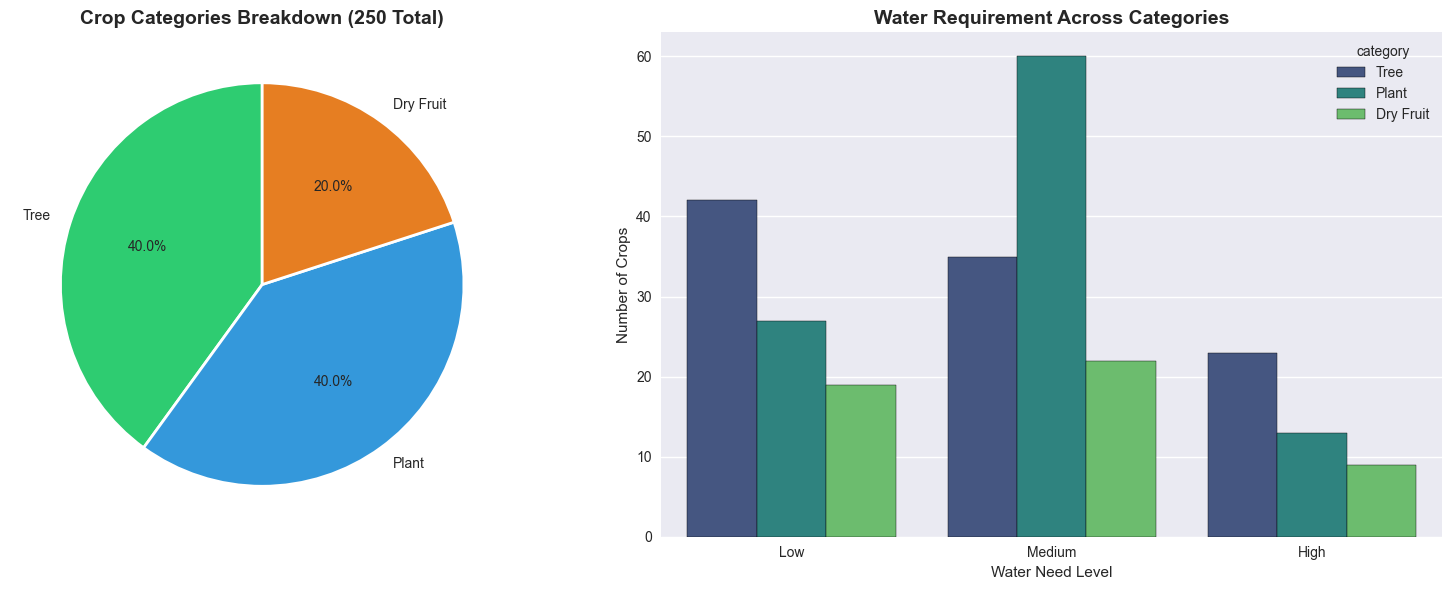

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Category Distribution Pie Chart
cat_counts = df['category'].value_counts()
colors = ['#2ecc71', '#3498db', '#e67e22']
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Crop Categories Breakdown (250 Total)', fontsize=14, fontweight='bold')

# Graph 2: Water Need by Category
sns.countplot(data=df, x='water_need', hue='category', palette='viridis', ax=axes[1], edgecolor='black')
axes[1].set_title('Water Requirement Across Categories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Water Need Level')
axes[1].set_ylabel('Number of Crops')

plt.tight_layout()
plt.show()

C:\Users\saadn\AppData\Local\Temp\ipykernel_3032\1980971739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='grow_days', palette='pastel', ax=axes[0])


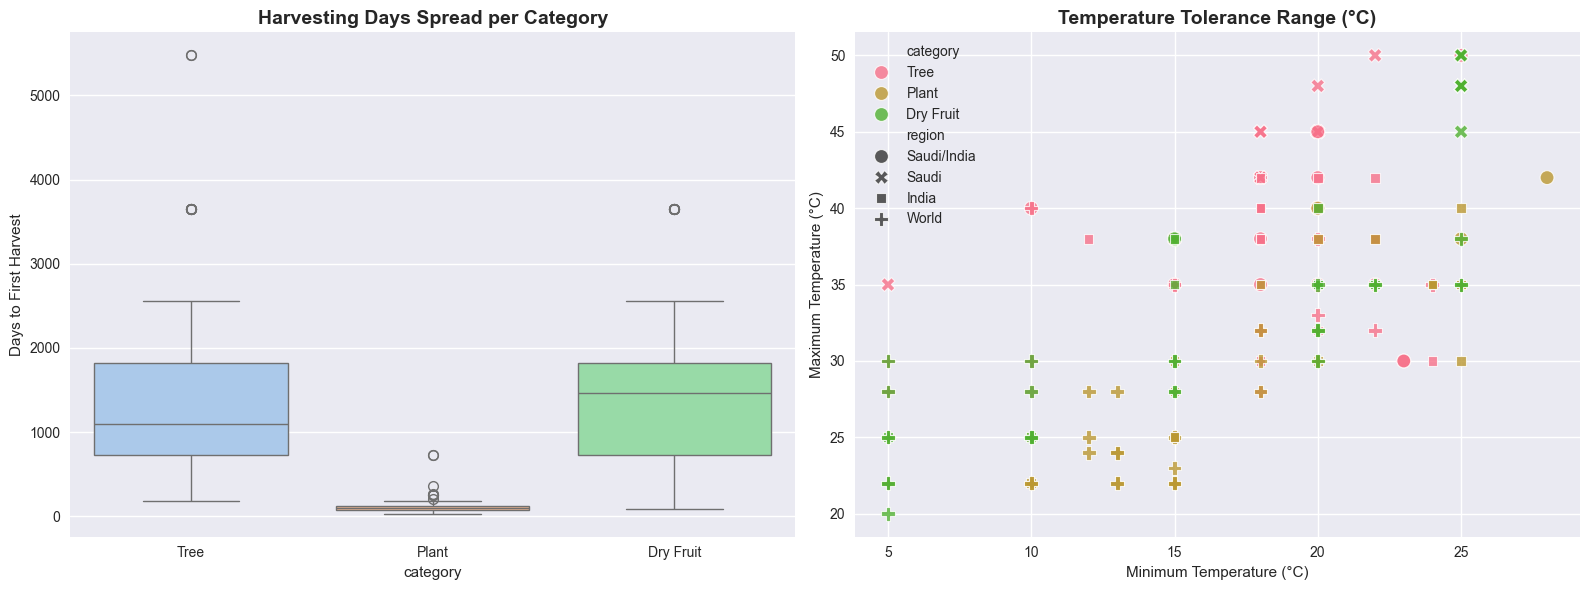

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 3: Harvesting Time (Grow Days) Boxplot
sns.boxplot(data=df, x='category', y='grow_days', palette='pastel', ax=axes[0])
axes[0].set_title('Harvesting Days Spread per Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Days to First Harvest')

# Graph 4: Min vs Max Temp Tolerance Scatter Plot
sns.scatterplot(data=df, x='temp_min', y='temp_max', hue='category', style='region', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('Temperature Tolerance Range (°C)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Minimum Temperature (°C)')
axes[1].set_ylabel('Maximum Temperature (°C)')

plt.tight_layout()
plt.show()

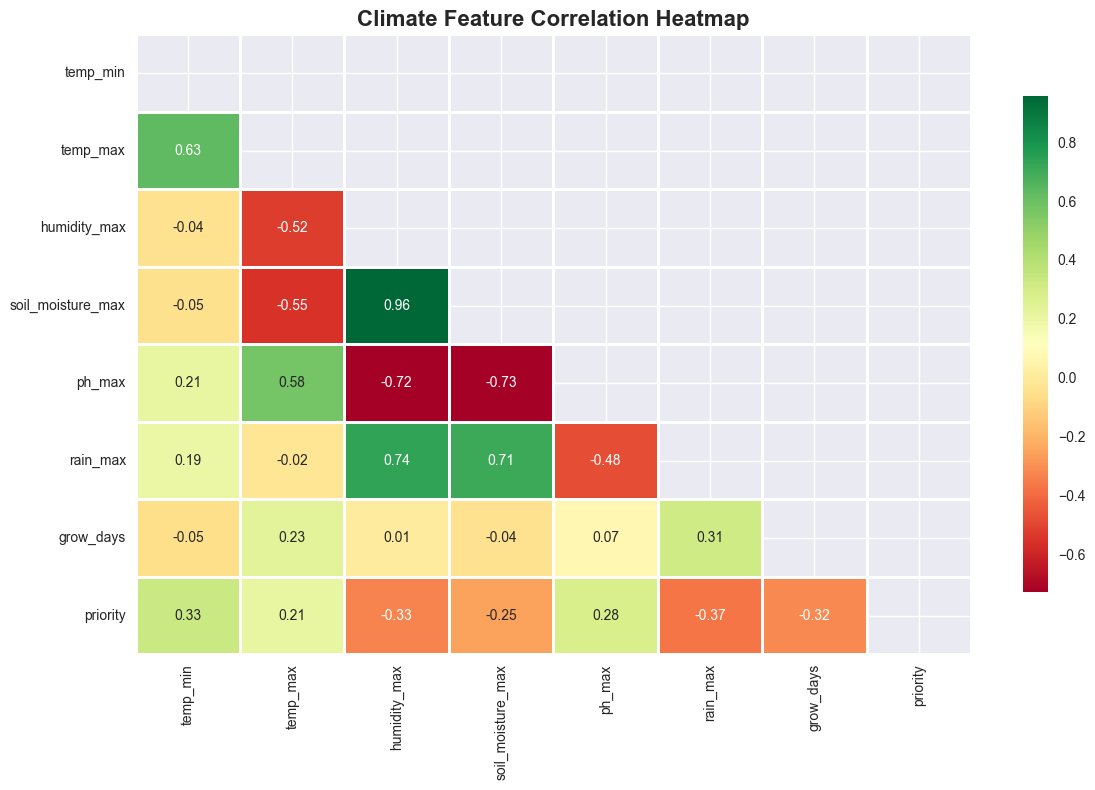

In [7]:
plt.figure(figsize=(12, 8))

# Filter numeric features only
numeric_df = df[['temp_min', 'temp_max', 'humidity_max', 'soil_moisture_max', 'ph_max', 'rain_max', 'grow_days', 'priority']]
corr = numeric_df.corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.8, cbar_kws={"shrink": .8})
plt.title('Climate Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\saadn\AppData\Local\Temp\ipykernel_3032\1597755702.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', palette='Set2', ax=axes[0], edgecolor='black')


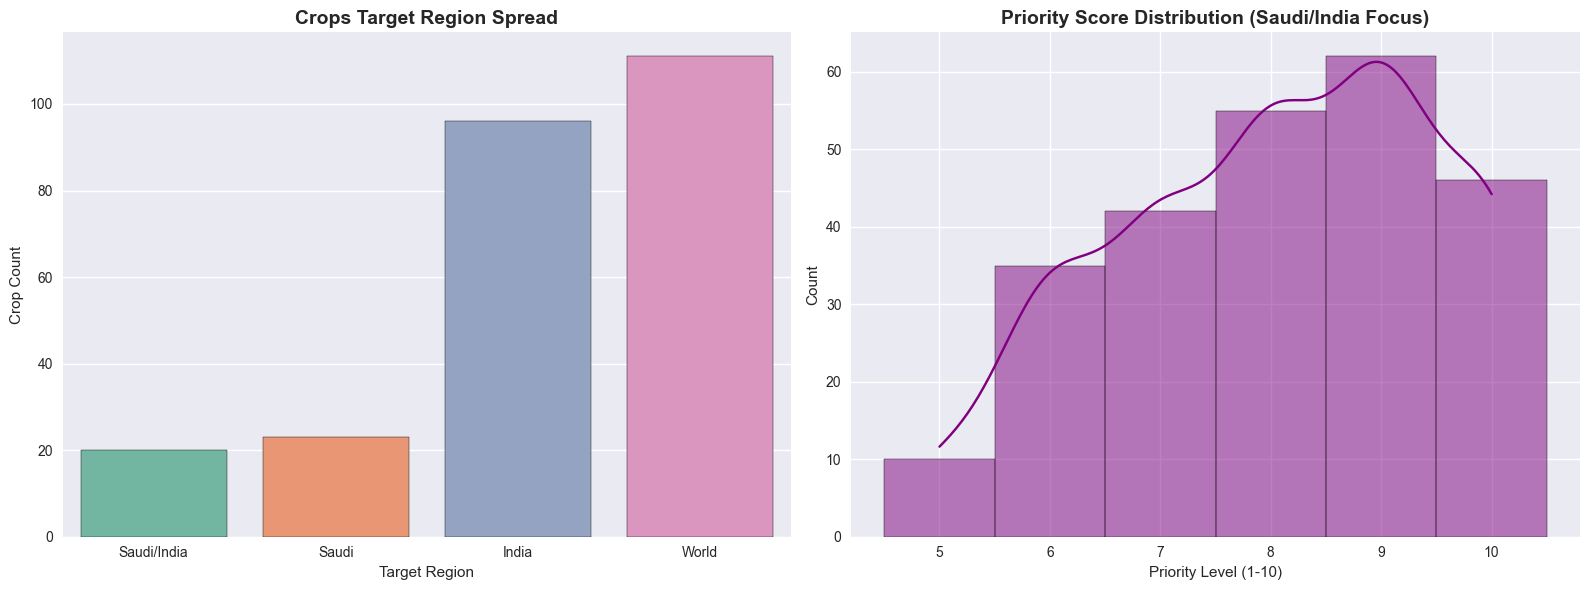

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 5: Geographical Priority Regions
sns.countplot(data=df, x='region', palette='Set2', ax=axes[0], edgecolor='black')
axes[0].set_title('Crops Target Region Spread', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Region')
axes[0].set_ylabel('Crop Count')

# Graph 6: Priority Distribution
sns.histplot(data=df, x='priority', discrete=True, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Priority Score Distribution (Saudi/India Focus)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Priority Level (1-10)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
print("="*60)
print(" 🌵 TOP 12 HIGH-HEAT RESISTANT CROPS (Max Temp >= 45°C) 🌵")
print("="*60)

# Filter crops that survive extreme desert heat
heat_survivors = df[df['temp_max'] >= 45].sort_values(by=['temp_max', 'priority'], ascending=[False, False])

for idx, row in heat_survivors.head(12).iterrows():
    print(f"• {row['name']:25s} | Category: {row['category']:10s} | Max Temp: {row['temp_max']}°C | Water Need: {row['water_need']}")

print("="*60)
print("✅ EDA Completed Successfully! Dataset is fully ready for Feature Engineering & Model Training.")

 🌵 TOP 12 HIGH-HEAT RESISTANT CROPS (Max Temp >= 45°C) 🌵
• Date Palm                 | Category: Tree       | Max Temp: 50°C | Water Need: Low
• Ajwa Date                 | Category: Dry Fruit  | Max Temp: 50°C | Water Need: Low
• Medjool Date              | Category: Dry Fruit  | Max Temp: 50°C | Water Need: Low
• Safawi Date               | Category: Dry Fruit  | Max Temp: 50°C | Water Need: Low
• Ghaf Tree                 | Category: Tree       | Max Temp: 50°C | Water Need: Low
• Mabroom Date              | Category: Dry Fruit  | Max Temp: 48°C | Water Need: Low
• Sukkari Date              | Category: Dry Fruit  | Max Temp: 48°C | Water Need: Low
• Acacia                    | Category: Tree       | Max Temp: 48°C | Water Need: Low
• Khudri Date               | Category: Dry Fruit  | Max Temp: 48°C | Water Need: Low
• Kholas Date               | Category: Dry Fruit  | Max Temp: 48°C | Water Need: Low
• Sagai Date                | Category: Dry Fruit  | Max Temp: 48°C | Water Need: L